# A place to toy around with spaceprime stuff
Notes are in my Obsidian vault. 
Note to self- I'm using the spaceprime conda environment.

# Function to convert raster stack to K values

I'm writing a function to convert a single raster or multiple rasters to local carrying capacities (K) with the possibility of a linear, hinge, or sigmoid transformation

This is a basic function to transform a raster to local carrying capacity (K) values. This function was created with the idea of taking in presence probability/habitat suitability rasters scaled from 0 to 1, where 0 is no suitability and 1 is the highest suitability. However, it is flexible enough to accomodate other continuous rasters that can be coaxed to a 0 to 1 scale with the operation `(data - np.min(data)) / (np.max(data) - np.min(data))` by setting the `normalize` flag to `True`. 
- The "linear" transformation multiplies the input (raw or transformed) values by the maximum local carrying capacity (max_local_k).
- The "hinge" transformation creates a raster where values below the `threshold` value are set to zero and values about the `threshold` value are set to 1. Note, this transformation is applied *after* normalizing if the `normalize` flag is set to `True`.
- The "sigmoid" transformation applies a sigmoid function to the data using Eq. 1 from [Frazier and Wang 2013, Modeling landscape structure response across a gradient of land cover intensity](https://www.researchgate.net/publication/257319938_Modeling_landscape_structure_response_across_a_gradient_of_land_cover_intensity), where an `inflection_point` and `slope` are specified. The `inflection_point` can be thought of like a `threshold` value, where original values below this value descend quicker to zero, and values about this value increase quicker to 1. The slope determines how fast values change on either side of the inflection point. A sufficiently steep slope makes this a hinge function, while a sufficiently shallow slope makes this a linear function.

In [1]:
import numpy as np
def raster_to_k(raster, transformation = "linear", max_local_k = 100, normalize = False, threshold = None, inflection_point = 0.5, slope = 0.05):

    d = raster.filled(0)

    if normalize:
        def normalize(rast):
            return (rast - np.min(rast)) / (np.max(rast) - np.min(rast))
        
        d = normalize(d)
    
    if transformation == "linear":
        t = d * max_local_k
        t = np.ceil(t)

    if transformation == "hinge":
        t = d
        t[t >= threshold] = max_local_k
        t[t < threshold] = 0

    if transformation == "sigmoid":
        def sigmoid(x, a, b):
            y = 1.0 / (1.0 + np.ma.exp(-(x - a) / b))
            return(y)
        
        sigmoid_v = np.vectorize(sigmoid)
        t = sigmoid_v(d, inflection_point, slope) * max_local_k
        t = np.ceil(t)
    

    return(t.astype(int))
    
  

## Migration matrix from deme sizes
This is a skeleton to facilitate creating a migration matrix from a matrix of deme sizes.  
The formula for scaling the migration rates, which is always recommended is:  
mig donor -> recipient = (recipient size / donor size) * rate  
(we're thinking backward in time)  

In `migration_matrix()`, migration can occur in four directions from the focal deme unless they are at the edge of the matrix. In `migration_matrix_diagonal()`, diagonal migration is also allowed. I'm not sure if I want to allow diagonal in the final implementation, but keeping it here for posterity.

In [2]:
import numpy as np

def migration_matrix(populations, rate, scale=True):
    d = populations.shape[0] * populations.shape[1]
    M = np.zeros((d, d))
    
    for i in range(populations.shape[0]):
        for j in range(populations.shape[1]):
            current_index = i * populations.shape[1] + j
            # check the neighboring populations and calculate the migration rates. Looping through tuples was a neat trick! Saved a lot of time.
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                # check for edges
                if 0 <= i + di < populations.shape[0] and 0 <= j + dj < populations.shape[1]:
                    neighbor_index = (i + di) * populations.shape[1] + (j + dj)
                    if scale:
                        # mig = donor / recipient * rate unless the pop size is zero
                        M[current_index, neighbor_index] = populations[i + di, j + dj] / populations[i, j] * rate if populations[i, j] != 0 else 0
                    else:
                        M[current_index, neighbor_index] = rate


    return M


In [6]:
import numpy as np

def migration_matrix_diagonal(populations, rate):
    d = populations.shape[0] * populations.shape[1]
    M = np.zeros((d, d))

    for i in range(populations.shape[0]):
        for j in range(populations.shape[1]):
            current_index = i * populations.shape[1] + j
            # Check the neighboring populations and calculate the migration rates
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if 0 <= i + di < populations.shape[0] and 0 <= j + dj < populations.shape[1] and not (di == 0 and dj == 0):
                        neighbor_index = (i + di) * populations.shape[1] + (j + dj)
                        M[current_index, neighbor_index] = populations[i + di, j + dj] / populations[i, j] * rate if populations[i, j] != 0 else 0

    # Set the diagonal to zero
    np.fill_diagonal(M, 0)

    return M




## 2D Stepping Stone model

Now to write a basic function! This will read in a single raster and create an msprime demography object with that single raster. I updated the function to use the `migration_matrix()` function, which is faster than the original implementation.  
`initial_size` is the local population size for each deme in the model  
`rate` is the migration rate between populations. Can be a single numerical value or a matrix that corresponds to all migration edges in the model.  
`scale` is a logical, determining if the migration rates should be scaled by the donor and recipient population sizes (True) or not. True is the default, since this is recommended behavior.


In [3]:
import msprime
import numpy as np

def stepping_stone2d(initial_size, rate, scale=True):
    assert len(initial_size.shape) <= 3

    n, m = initial_size.shape
    N = n * m
    model = msprime.Demography.isolated_model(initial_size.reshape(N))

    # set population names
    for j in range(n):
        for k in range(m):
            index = j * m + k
            model.populations[index].name = f"pop_{j}_{k}"

    if np.array(rate).ndim == 0:
        if scale:
            model.migration_matrix = migration_matrix(initial_size, rate, scale=True)
        else: 
            model.migration_matrix = migration_matrix(initial_size, rate, scale=False)
    else:
        assert rate.shape == (N, N), f"Expected a migration matrix with the shape {(N, N)} and instead got {rate.shape}"
        model.migration_matrix = rate

    
    return model

## Demographic changes based on landscape change to 2D stepping stone model

The `model` is an `msprime.Demography` object that needs to be initialized using `stepping_stone_2d()`.  
`k_stack` is a 3D numpy array of the local carrying capacities across the landscape for each timestep except the most current timestep.  
`timestep` is the amount of time that passes between each landscape change, measured in generations. For instance, if each landscape is 100 years apart and the generation time of the organism is 1 year, `timestep` is 100. However, if the generation time of the organism is 2 years, `timestep` is 50. 


In [4]:
import msprime
import numpy as np
def add_landscape_change(model, k_stack, timestep = 1, rate = 0.001, scale=True):
    # iterate through the first dimension of a 3D array, where the array represents different time steps of population size change
    for step in range(1, k_stack.shape[0]):
        # get the population size values of the current array
        kmat = k_stack[step]

        # get the population size values of array from the previous time step
        kmat_prev = k_stack[step - 1]

        # get the shape of the array
        n, m = kmat.shape

        ##### Update population sizes #####
        # add population size changes according to the values of the current array
        for j in range(n):
            for k in range(m):
                # only update the population size if it is different from the previous time point
                if kmat[j, k] != kmat_prev[j, k]:
                    # add a demographic change to each cell in the raster
                    model.add_population_parameters_change(time=step * timestep, population=f"pop_{j}_{k}", initial_size=kmat[j, k])

        ##### Update migration rates #####
        # calc migration rates for previous time step 
        # mig_prev = migration_matrix(kmat_prev, rate = rate)
        # # calc migration rates for current time step
        # mig_curr = migration_matrix(kmat, rate = rate)

        # # get difference between current and previous migration matrices
        # mig_diff = np.subtract(mig_curr, mig_prev)

        # # get indices of where the migration rates change
        # change_ind = np.transpose(np.nonzero(mig_diff != 0))

        # # loop through the indices of the migration rates that changed and add a migration rate change
        # for ind_pair in change_ind:
            
        #     # the index we get from the migration matrix is the ravelled index, so we need to unravel it to get the original population size matrix index
        #     source_ind = np.unravel_index(ind_pair[0], kmat.shape)
        #     dest_ind = np.unravel_index(ind_pair[1], kmat.shape)

        #     model.add_migration_rate_change(time = step * timestep, rate = mig_curr[ind_pair[0]][ind_pair[1]], source = f"pop_{source_ind[0]}_{source_ind[1]}", dest = f"pop_{dest_ind[0]}_{dest_ind[1]}")


        # add migration rate change for each time step
        # ## iterate through the population sizes
        for i in range(n):
            for j in range(m):
                ## also index the neighboring cells
                for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    ## check for edges
                    if 0 <= i + di < kmat.shape[0] and 0 <= j + dj < kmat.shape[1]:
                        ## only update migration if the donor and recipient population sizes are different between time points
                        if kmat[i + di, j + dj] != kmat_prev[i + di, j +dj] and kmat[i, j] != kmat_prev[i, j]:
                            if scale:
                                ## mig = donor / recipient * rate unless the pop size is zero
                                r = kmat[i + di, j + dj] / kmat[i, j] * rate if kmat[i, j] != 0 else 0
                                model.add_migration_rate_change(time = step * timestep, rate = r, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
                            else:
                                model.add_migration_rate_change(time = step * timestep, rate = rate, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
                    
                            
                
    
    return model


## Add collecting phase to 2D stepping stone model

The `split_array()` function splits any 1D array into equal-sized chunks, but makes sure the chunk size is never less than 2. If the chunk is less than 2, the chunk is merged with the chunk before it. 

`ancestral_size` is the size of the ancestral population that all demes coalesce to. This is the "collecting phase" of the simulation and corresponds to the time when space no longer matters for genetic diversity. 

`collecting_time` is the time in generations that the metapopulation merges into the ancestral population(s)

In [5]:
import msprime
import numpy as np

def add_nonspatial_phase(model, ancestral_size, collecting_time):
    # add an ancestral population
    model.add_population(name = "ANC", initial_size=ancestral_size)

    # get names of populations for initiating the collecting phase
    pop_names = [[pop.name] for pop in model.populations if pop.name != "ANC"]
    
    # add the time when the spatial simulation collapses into the collecting phase
    [model.add_population_split(time = collecting_time, derived = name, ancestral = "ANC") for name in pop_names]

    return model

## Model post-processing

### Per-deme diversity
This is a function to get the per-deme Tajima's pi from each deme that has individuals in a simulation. The output is a matrix the same size as the K matrix, filled with diversity stats for each deme with individuals in the final generation. The diversity statistic is calculated on a tree sequence with mutations for now (rather than the branch stat), but once I need to I'll extend it. 

In [6]:
import re

# ts is a tree sequence
# k_dim is the shape of the K matrix
def get_diversity_matrix(ts, k_dim):

    # calculate diversity for each population that has individuals
    div = np.zeros(len(ts.populations()) - 1)
    for i in range(len(ts.populations()) - 1):
        if len(ts.samples(i)) > 0:
            div[i] = ts.diversity(ts.samples(i))
    
    # empty matrix to populate
    div_mat = np.full(shape=k_dim, fill_value= np.nan)

    # loop through the sampled populations, extract their index, and populate div_mat with those values
    for i in range(len(ts.populations()) - 1):
        
        if len(ts.samples(i)) > 0:
            # extract the indices from the population names
            ind = re.findall(r'\d+', ts.populations()[i].metadata['name'])
            # convert the string indices to integers and index the div_mat
            div_mat[int(ind[0]), int(ind[1])] = div[i]
        #else:
        #    div_mat[int(ind[0]), int(ind[1])] = np.nan

        
    return div_mat

## Model testing

Read in the multiband raster

In [7]:
import rasterio

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 110, 'height': 117, 'count': 21, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.0833333329997884, 0.0, -52.35847273325492,
       0.0, -0.08333333300085433, -21.508472496174495), 'blockysize': 1, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}


In [8]:
# make sure both rasters get read it
r.shape

(21, 117, 110)

In [9]:
k = raster_to_k(r, transformation="linear", max_local_k = 100)

k.shape

(21, 117, 110)

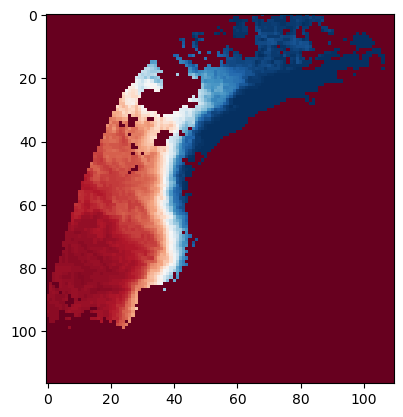

In [10]:
from matplotlib import pyplot

pyplot.imshow(k[0], cmap='RdBu')

pyplot.show() 

In [59]:
m = stepping_stone2d(k[0], rate = 0.0001)

In [53]:
m = add_landscape_change(model = m, k_stack = k[[0, 1, 2, 3, 4, 5, 6]], timestep = 1000)

In [54]:
m = add_nonspatial_phase(m, ancestral_size=500000, collecting_time=10000)

In [55]:
m.sort_events()

In [60]:
nzp = []
for i in range(len(m.populations)):
    if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
        nzp.append(m.populations[i].name)
    # set the default sampling time to the present
    m.populations[i].default_sampling_time = 0

# sample 2 individuals from each population
pop_dict = {key: 2 for key in nzp}

ts = msprime.sim_ancestry(pop_dict, sequence_length=1e7, demography = m, recombination_rate=1e-9, record_provenance=False)

KeyboardInterrupt: 

In [57]:
mu = msprime.sim_mutations(ts, rate = 1e-8)

In [58]:
mu

In [142]:
div_mat = get_diversity_matrix(mu, k[0].shape)

KeyboardInterrupt: 

In [130]:
# 8.075260718424094e-06
np.nanmean(div_mat)

8.075260718424094e-06

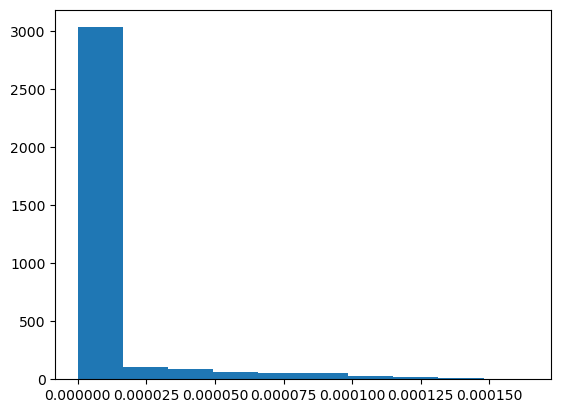

In [133]:
from matplotlib import pyplot

pyplot.hist(np.ravel(div_mat))

pyplot.show() 

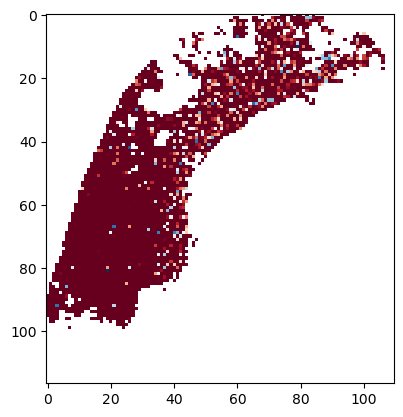

In [131]:
from matplotlib import pyplot

pyplot.imshow(div_mat, cmap='RdBu')

pyplot.show() 

In [31]:
div_mat[0:10, 0:10]

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]])

## Testing simulations with pre-specified matrices

In [62]:
import numpy as np
k = np.random.randint(0, 10, (2, 5, 5))
k


array([[[2, 1, 8, 1, 8],
        [8, 7, 6, 2, 3],
        [6, 5, 4, 5, 6],
        [6, 8, 3, 3, 1],
        [6, 3, 9, 7, 1]],

       [[8, 8, 4, 3, 4],
        [1, 2, 7, 8, 2],
        [7, 1, 2, 0, 9],
        [9, 6, 2, 3, 6],
        [8, 0, 4, 3, 3]]])

In [90]:

m = stepping_stone2d(k[0], rate = 0.001)

m = add_landscape_change(model = m, k_stack = k, timestep = 1000)

m = add_nonspatial_phase(m, ancestral_size=1e6, collecting_time=21000)

m.sort_events()

# get populations with at least two individuals to sample for coalescent simulations
nzp = []
for i in range(len(m.populations)):
    if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
        nzp.append(m.populations[i].name)

pop_dict = {key: 2 for key in nzp}

ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=1e-9, record_provenance=False)

ts = msprime.sim_mutations(ts, rate = 1e-7)

In [91]:
ts

In [88]:
div_mat = get_diversity_matrix(ts, k[0].shape)

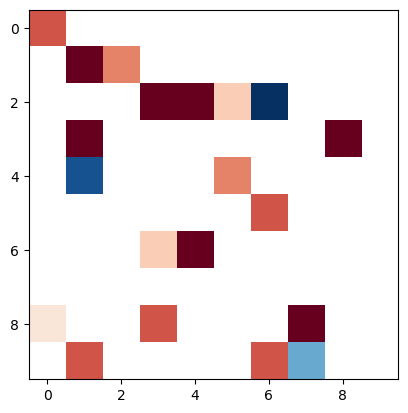

In [89]:
from matplotlib import pyplot

pyplot.imshow(div_mat, cmap='RdBu')

pyplot.show() 

### Debug parent node <= child node error

In [74]:
def sim(k, num_layers, ancestral_ne, recomb_rate):
    m = stepping_stone2d(k[0], rate = 0.001)

    m = add_landscape_change(model = m, k_stack = k[0:num_layers], timestep = 1000)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, collecting_time=num_layers * 1000 + 1000)

    m.sort_events()

    # get populations with at least two individuals to sample for coalescent simulations
    nzp = []
    for i in range(len(m.populations)):
        if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
            nzp.append(m.populations[i].name)

    pop_dict = {key: 2 for key in nzp}

    ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=recomb_rate, record_provenance=False)

    return f"num_layers = {num_layers}, ancestral_ne = {ancestral_ne}, recomb_rate = {recomb_rate}, success = Yes\n"



In [ ]:
# read in rasters and convert to K
import rasterio

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)


k = raster_to_k(r, transformation="linear", max_local_k = 100)

#### Experiment 1
I looped through the following parameter combination to see if there were any patterns:
- ancestral Ne = \[5000, 50000, 500000\]
- recombination = \[0, 1e-9]
- number of layers = \[3, 5, 10]

There was no pattern.

In [76]:
# loop through parameters and write the status to a file
for nl in [3, 5, 10]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss.txt', 'a') as f:
                    f.write(failure)

#### Experiment 2

I looped through the following parameter combination to see if there were any patterns:
- ancestral Ne = \[5000, 50000, 500000\]
- recombination = \[0, 1e-9]
- number of layers = 1

All ran successfully with 1 layer.

In [ ]:
# loop through parameters and write the status to a file
for nl in [1]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_k1.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_k1.txt', 'a') as f:
                    f.write(failure)

#### Experiment 3

I'm going to split the landscape in half, then see if a particular half has trouble. I'll probably continue this into smaller pieces until I find the smallest piece where I can recreate the error. I'm going to do the experiment for 3 layers, since it doesn't appear that the number of layers matters.

##### E3P1
Top half: This results in an error. Going to split it into a quarter.

In [84]:
# split K in half vertically
khalf = k[:, 0:59, :]
from matplotlib import pyplot

pyplot.imshow(khalf[0], cmap='RdBu')

pyplot.show() 

In [86]:
for nl in [3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = khalf, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_tophalf.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_tophalf.txt', 'a') as f:
                    f.write(failure)

##### E3P2
Top-right quarter

One parameter combo failed, but I had to run it twice, as the first round had all successes- probably due to random chance.

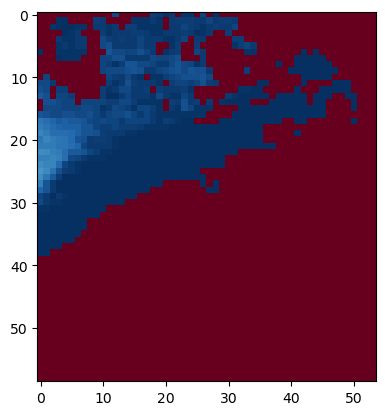

In [93]:
# top right quarter
ktr = k[:, 0:59, 56:]
from matplotlib import pyplot

pyplot.imshow(ktr[0], cmap='RdBu')

pyplot.show() 


In [90]:
for nl in [3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = ktr, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright.txt', 'a') as f:
                    f.write(failure)

##### E3P3
Top-left 10 x 10 of top-right quarter

All successes afrer quite a few repetitions. So, no problems here.

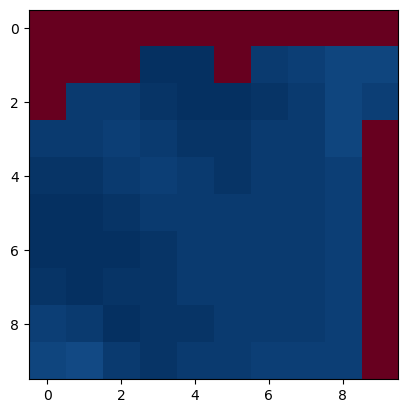

In [97]:
# top right quarter
kten = ktr[:, 0:10, 0:10]
from matplotlib import pyplot

pyplot.imshow(kten[3], cmap='RdBu')

pyplot.show() 

In [99]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = kten, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright10.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright10.txt', 'a') as f:
                    f.write(failure)

##### E3P4
Top-left 20 by 20 of top-right quadrant

Maybe there need to be more cells. Going to try this before moving to different section of the quadrant.

This resulted in some failures. I'll try the bottom half to narrow it down further. 

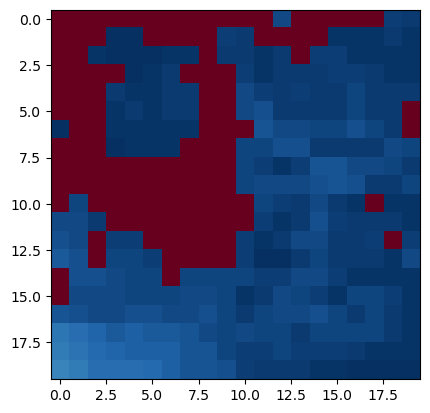

In [101]:
# top right quarter
ktwenty = ktr[:, 0:20, 0:20]
from matplotlib import pyplot

pyplot.imshow(ktwenty[0], cmap='RdBu')

pyplot.show() 

In [102]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = ktwenty, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20.txt', 'a') as f:
                    f.write(failure)

##### E3P4
Bottom half of the top-left 20 by 20 of top-right quadrant. That's a doozy.

This had some failures too! Time to get the left half.

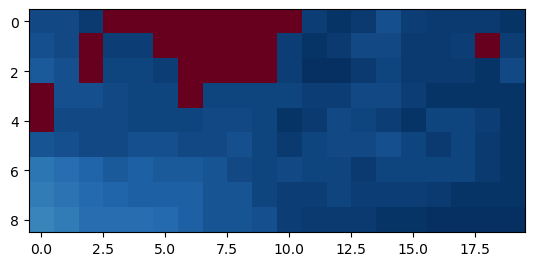

In [103]:
k20b = ktwenty[:, 11:, :]
from matplotlib import pyplot

pyplot.imshow(k20b[0], cmap='RdBu')

pyplot.show() 

In [110]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k20b, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf.txt', 'a') as f:
                    f.write(failure)

##### E3P5
Left half of the bottom half of the top-left 20 by 20 of top-right quadrant. That's an even bigger doozy.
After 132 reps, had a single failure. 

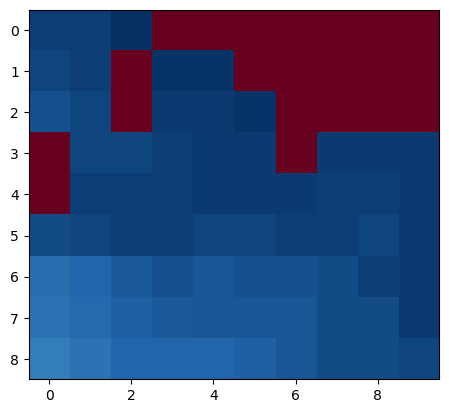

In [106]:
k20b10 = ktwenty[:, 11:, 0:10]
from matplotlib import pyplot

pyplot.imshow(k20b10[0], cmap='RdBu')

pyplot.show() 

In [111]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k20b10, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf10.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf10.txt', 'a') as f:
                    f.write(failure)

##### Create a minimum example to put on github
Reducing the parameters needed to explore that reproduces the error for github.

In [122]:
# I'm repeating this a few times to account for random chance of success/failure
outfile = '/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_github.txt'

for nl in [3] * 200:
    try:
        success = sim(k = k20b10, num_layers = nl, ancestral_ne = 50000, recomb_rate = 0)
        with open(outfile, 'a') as f:
            f.write(success)
    except Exception as e:
        er = str(e)
        failure = f"num_layers = {nl}, ancestral_ne = 50000, recomb_rate = 0, success = No, error = {er}\n"
        with open(outfile, 'a') as f:
            f.write(failure)